In [1]:
import sys

In [2]:
sys.path.append("../..")
# sys.path.append("/home/pat/projects/pytorch-receptive-field")

In [3]:
from matplotlib import pyplot as plt 
import pandas as pd
import torch

In [4]:
from xaikd import models

# from torch_receptive_field import receptive_field
from receptivefield.pytorch import PytorchReceptiveField

import numpy as np

In [5]:
model_name = "cifar100-resnet18-p1"
model = models.get_model(model_name)

In [6]:
for child in model.named_children():
    print(child)

('conv1', Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False))
('bn1', BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True))
('relu', ReLU(inplace=True))
('maxpool', Identity())
('layer1', Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (b

In [9]:
id(model.layer4[-1])

140503111689552

In [11]:
id(model.layer4[0]), id(model.layer4[1])

(140503111689360, 140503111689552)

In [38]:
def count_parameters(module):
    
    count = 0
    for _, parameter in module.named_parameters():
        if not parameter.requires_grad: continue
        
        count += parameter.numel()
        
    return count
    
def count_total_parameters():
    arr = []
    for name, module in model.named_children():
        count = count_parameters(module)        
        arr.append(dict(
            module=name,
            params_count=count,
        ))
        
    df = pd.DataFrame(arr)
    
    df["percentage"] = df.params_count / df.params_count.values.sum()

    return df 

df = count_total_parameters(model)

df

,module,params_count,percentage
0,conv1,1728,0.000154
1,bn1,128,0.000011
2,relu,0,0.000000
3,maxpool,0,0.000000
4,layer1,147968,0.013188
5,layer2,525568,0.046842
6,layer3,2099712,0.187138
7,layer4,8393728,0.748095
8,avgpool,0,0.000000
9,fc,51300,0.004572


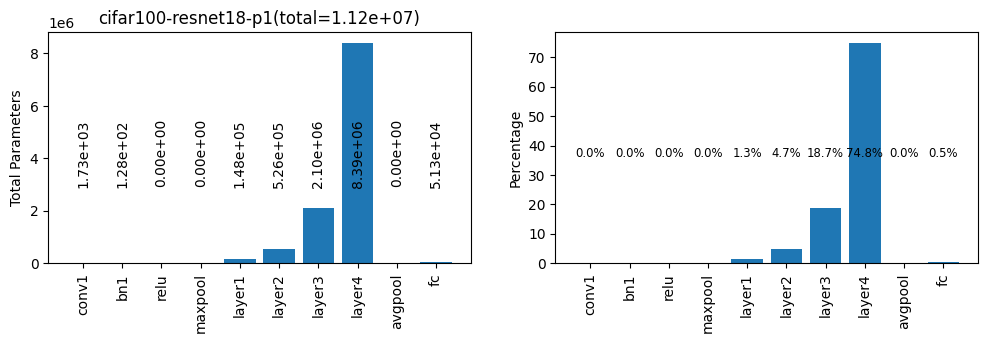

In [67]:
def ano():
    
    ncols = 2
    nrows = 1
    plt.figure(figsize=(6*ncols, 3*nrows))
    
    ticks = np.arange(0, df.shape[0])
    plt.subplot(nrows, ncols, 1)
    total =  df.params_count.sum()
    plt.title(f"{model_name}(total={total:.2e})")
    plt.bar(ticks, df.params_count)

    plt.xticks(ticks, df.module, rotation=90)
    
    for t in ticks:
        count = df.params_count[t]
        plt.text(t, df.params_count.max() / 2, f"{count:.2e}", rotation=90, va="center", ha="center")
    
    plt.ylabel("Total Parameters")
    
    plt.subplot(nrows, ncols, 2)
    plt.bar(ticks, df.percentage * 100)
    plt.ylabel("Percentage")
    plt.xticks(ticks, df.module, rotation=90)

    for t in ticks:
        count = df.percentage[t]  * 100
        plt.text(t, (df.percentage.max() / 2)*100, f"{count:.1f}%", va="center", ha="center", fontsize="small")
ano()

In [103]:
class ResNetWrapper(torch.nn.Module):
    def __init__(self):
        super().__init__()
        
        self.model = models.get_model("cifar100-resnet18-p1")
        
    def forward(self, x):
        x = self.model.conv1(x)
        x = self.model.bn1(x)
        x = self.model.maxpool(x)
        
        self.feature_maps = []
        
        for layer in ["layer1", "layer2", "layer3", "layer4"]:
            mod = getattr(self.model, layer)
            out = mod(x)
            print(f"layer={layer}: in: {x.shape}   | out: {out.shape}")
            self.feature_maps.append(out)
            x = out

In [104]:
    
def ano():
    return ResNetWrapper()

rf = PytorchReceptiveField(ano)
rf_params = rf.compute(input_shape = (32, 32, 3))

[2023-06-19 09:41:57,507][ INFO][pytorch.py]::Feature maps shape: [GridShape(n=1, w=32, h=32, c=64), GridShape(n=1, w=16, h=16, c=128), GridShape(n=1, w=8, h=8, c=256), GridShape(n=1, w=4, h=4, c=512)]
[2023-06-19 09:41:57,508][ INFO][pytorch.py]::Input shape       : GridShape(n=1, w=32, h=32, c=3)


layer=layer1: in: torch.Size([1, 64, 32, 32])   | out: torch.Size([1, 64, 32, 32])
layer=layer2: in: torch.Size([1, 64, 32, 32])   | out: torch.Size([1, 128, 16, 16])
layer=layer3: in: torch.Size([1, 128, 16, 16])   | out: torch.Size([1, 256, 8, 8])
layer=layer4: in: torch.Size([1, 256, 8, 8])   | out: torch.Size([1, 512, 4, 4])
layer=layer1: in: torch.Size([1, 64, 32, 32])   | out: torch.Size([1, 64, 32, 32])
layer=layer2: in: torch.Size([1, 64, 32, 32])   | out: torch.Size([1, 128, 16, 16])
layer=layer3: in: torch.Size([1, 128, 16, 16])   | out: torch.Size([1, 256, 8, 8])
layer=layer4: in: torch.Size([1, 256, 8, 8])   | out: torch.Size([1, 512, 4, 4])
layer=layer1: in: torch.Size([1, 64, 32, 32])   | out: torch.Size([1, 64, 32, 32])
layer=layer2: in: torch.Size([1, 64, 32, 32])   | out: torch.Size([1, 128, 16, 16])
layer=layer3: in: torch.Size([1, 128, 16, 16])   | out: torch.Size([1, 256, 8, 8])
layer=layer4: in: torch.Size([1, 256, 8, 8])   | out: torch.Size([1, 512, 4, 4])
layer=l

[2023-06-19 09:41:57,777][ INFO][base.py]::Estimated receptive field for feature map [0]: ReceptiveFieldDescription(offset=(0.5, 0.5), stride=(1.0, 1.0), size=Size(w=11, h=11))
[2023-06-19 09:41:57,777][ INFO][base.py]::Estimated receptive field for feature map [1]: ReceptiveFieldDescription(offset=(0.5, 0.5), stride=(2.0, 2.0), size=Size(w=25, h=25))
[2023-06-19 09:41:57,778][ INFO][base.py]::Estimated receptive field for feature map [2]: ReceptiveFieldDescription(offset=(11.0, 11.0), stride=(0.0, 0.0), size=Size(w=32, h=32))
[2023-06-19 09:41:57,778][ INFO][base.py]::Estimated receptive field for feature map [3]: ReceptiveFieldDescription(offset=(16.0, 16.0), stride=(0.0, 0.0), size=Size(w=32, h=32))


layer=layer1: in: torch.Size([1, 64, 32, 32])   | out: torch.Size([1, 64, 32, 32])
layer=layer2: in: torch.Size([1, 64, 32, 32])   | out: torch.Size([1, 128, 16, 16])
layer=layer3: in: torch.Size([1, 128, 16, 16])   | out: torch.Size([1, 256, 8, 8])
layer=layer4: in: torch.Size([1, 256, 8, 8])   | out: torch.Size([1, 512, 4, 4])
layer=layer1: in: torch.Size([1, 64, 32, 32])   | out: torch.Size([1, 64, 32, 32])
layer=layer2: in: torch.Size([1, 64, 32, 32])   | out: torch.Size([1, 128, 16, 16])
layer=layer3: in: torch.Size([1, 128, 16, 16])   | out: torch.Size([1, 256, 8, 8])
layer=layer4: in: torch.Size([1, 256, 8, 8])   | out: torch.Size([1, 512, 4, 4])
layer=layer1: in: torch.Size([1, 64, 32, 32])   | out: torch.Size([1, 64, 32, 32])
layer=layer2: in: torch.Size([1, 64, 32, 32])   | out: torch.Size([1, 128, 16, 16])
layer=layer3: in: torch.Size([1, 128, 16, 16])   | out: torch.Size([1, 256, 8, 8])
layer=layer4: in: torch.Size([1, 256, 8, 8])   | out: torch.Size([1, 512, 4, 4])
layer=l

In [101]:
rf_params

[FeatureMapDescription(size=Size(w=32, h=32), rf=ReceptiveFieldDescription(offset=(0.5, 0.5), stride=(1.0, 1.0), size=Size(w=11, h=11))),
 FeatureMapDescription(size=Size(w=16, h=16), rf=ReceptiveFieldDescription(offset=(0.5, 0.5), stride=(2.0, 2.0), size=Size(w=25, h=25))),
 FeatureMapDescription(size=Size(w=8, h=8), rf=ReceptiveFieldDescription(offset=(11.0, 11.0), stride=(0.0, 0.0), size=Size(w=32, h=32))),
 FeatureMapDescription(size=Size(w=4, h=4), rf=ReceptiveFieldDescription(offset=(16.0, 16.0), stride=(0.0, 0.0), size=Size(w=32, h=32)))]

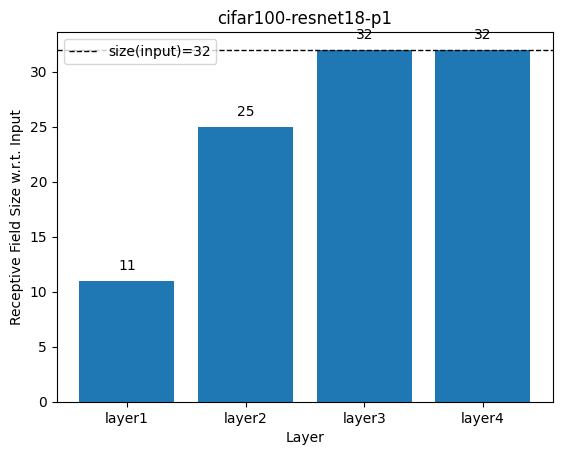

In [128]:
def ano():
    plt.title(model_name)
    
    
    plt.axhline(32, ls="--", lw=1, color="k", label="size(input)=32")
    
    
    rfs = list(map(lambda param: param.rf.size.w, rf_params))
    
    ticks = np.arange(len(rfs))
    
    for t in ticks:
        plt.text(t, rfs[t]+1, rfs[t], ha="center")
    
    plt.bar(ticks, rfs)
    plt.ylabel("Receptive Field Size w.r.t. Input")
    plt.xticks(ticks, ["layer1", "layer2", "layer3", "layer4"])
    plt.legend()
    plt.xlabel("Layer")
    
#     for name, rf_param in zip(["layer1", "layer2", "layer3", "layer4"], rf_params):
#         pass
        
    
ano()

In [102]:
rf_params

[FeatureMapDescription(size=Size(w=32, h=32), rf=ReceptiveFieldDescription(offset=(0.5, 0.5), stride=(1.0, 1.0), size=Size(w=11, h=11))),
 FeatureMapDescription(size=Size(w=16, h=16), rf=ReceptiveFieldDescription(offset=(0.5, 0.5), stride=(2.0, 2.0), size=Size(w=25, h=25))),
 FeatureMapDescription(size=Size(w=8, h=8), rf=ReceptiveFieldDescription(offset=(11.0, 11.0), stride=(0.0, 0.0), size=Size(w=32, h=32))),
 FeatureMapDescription(size=Size(w=4, h=4), rf=ReceptiveFieldDescription(offset=(16.0, 16.0), stride=(0.0, 0.0), size=Size(w=32, h=32)))]

In [108]:
class ResNetRelativeWrapper(torch.nn.Module):
    def __init__(self, layer):
        super().__init__()
        
        self.model = models.get_model("cifar100-resnet18-p1")
        self.layer = layer
        
    def forward(self, x):

        self.feature_maps = []
        
        mod = getattr(self.model, self.layer)
        x = mod(x)
        self.feature_maps.append(x)
        

rf = PytorchReceptiveField(lambda: ResNetRelativeWrapper("layer4"))
rf_params_ = rf.compute(input_shape = (8, 8, 256))

[2023-06-19 09:46:37,230][ INFO][pytorch.py]::Feature maps shape: [GridShape(n=1, w=4, h=4, c=512)]
[2023-06-19 09:46:37,231][ INFO][pytorch.py]::Input shape       : GridShape(n=1, w=8, h=8, c=256)
[2023-06-19 09:46:37,284][ INFO][base.py]::Estimated receptive field for feature map [0]: ReceptiveFieldDescription(offset=(4.0, 4.0), stride=(0.0, 0.0), size=Size(w=8, h=8))


In [ ]:
layer=layer1: in: torch.Size([1, 64, 32, 32])   | out: torch.Size([1, 64, 32, 32])
layer=layer2: in: torch.Size([1, 64, 32, 32])   | out: torch.Size([1, 128, 16, 16])
layer=layer3: in: torch.Size([1, 128, 16, 16])   | out: torch.Size([1, 256, 8, 8])
layer=layer4: in: torch.Size([1, 256, 8, 8])   | out: torch.Size([1, 512, 4, 4])

In [114]:
def ano():
    
    input_dims = [
        (32, 32, 64),
        (32, 32, 64),
        (16, 16, 128),
        (8, 8, 256)
    ]
    
    arr_rows = []
    for i in range(1, 4+1):
        layer = f"layer{i}"
        input_dim = input_dims[i-1]
        rf = PytorchReceptiveField(lambda: ResNetRelativeWrapper(layer))
        rf_params_ = rf.compute(input_shape = input_dim)
        
        arr_rows.append(dict(
            module=layer,
            input_spatial_size=input_dim[0],
            relative_rf=rf_params_[0].rf.size[0],
        ))
        
    return pd.DataFrame(arr_rows)
        
df_relative = ano()
df_relative

[2023-06-19 09:54:13,395][ INFO][pytorch.py]::Feature maps shape: [GridShape(n=1, w=32, h=32, c=64)]
[2023-06-19 09:54:13,395][ INFO][pytorch.py]::Input shape       : GridShape(n=1, w=32, h=32, c=64)
[2023-06-19 09:54:13,417][ INFO][base.py]::Estimated receptive field for feature map [0]: ReceptiveFieldDescription(offset=(0.5, 0.5), stride=(1.0, 1.0), size=Size(w=9, h=9))
[2023-06-19 09:54:13,524][ INFO][pytorch.py]::Feature maps shape: [GridShape(n=1, w=16, h=16, c=128)]
[2023-06-19 09:54:13,525][ INFO][pytorch.py]::Input shape       : GridShape(n=1, w=32, h=32, c=64)
[2023-06-19 09:54:13,541][ INFO][base.py]::Estimated receptive field for feature map [0]: ReceptiveFieldDescription(offset=(0.5, 0.5), stride=(2.0, 2.0), size=Size(w=15, h=15))
[2023-06-19 09:54:13,654][ INFO][pytorch.py]::Feature maps shape: [GridShape(n=1, w=8, h=8, c=256)]
[2023-06-19 09:54:13,655][ INFO][pytorch.py]::Input shape       : GridShape(n=1, w=16, h=16, c=128)
[2023-06-19 09:54:13,684][ INFO][base.py]::Esti

,module,input_spatial_size,relative_rf
0,layer1,32,9
1,layer2,32,15
2,layer3,16,14
3,layer4,8,8


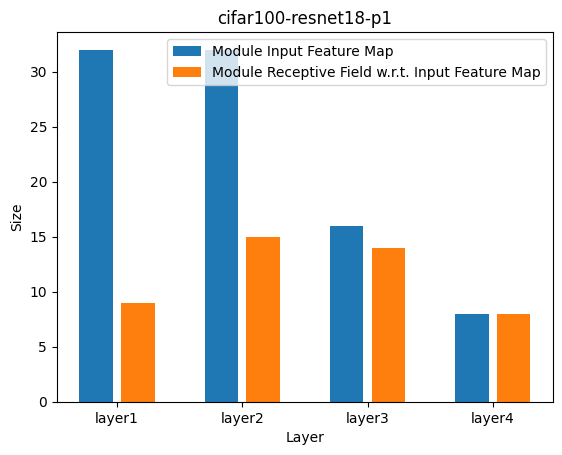

In [127]:
def ano():
    
    ticks = np.arange(4) * 3 
    
    plt.bar(ticks, df_relative.input_spatial_size, label="Module Input Feature Map")
    plt.bar(ticks+1, df_relative.relative_rf, label="Module Receptive Field w.r.t. Input Feature Map")

    plt.legend()
    plt.xticks(ticks+0.5, df_relative.module)
    plt.ylabel("Size")
    plt.title(model_name)
    plt.xlabel("Layer")
ano()